In [2]:
#데이터로딩
import pandas as pd
df = pd.read_csv('./data/gapminder.tsv',sep='\t')

In [3]:
df

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


In [4]:
#데이터 크기
df.shape

(1704, 6)

In [5]:
#데이터구조
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [103]:
#기초통계량
df.describe() #숫자컬럼만 계산

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [104]:
#기초통계량
df.describe( include='object') #문자칼럼만 계산
# count - 총개수
# unique - 유일한 값 개수
# top - 최빈값(가장 많은 값)
# freq - 초빈도수(최빈값이 보이는 횟수)


,country,continent
count,1704,1704
unique,142,5
top,Afghanistan,Africa
freq,12,624


In [10]:
# 값 추출 -하는 여러가지 방법
# df['칼럼명'] 1개 칼럼 추출(시리즈타입-1차원)
# df[['칼럼명1','칼럼명2',...]] 2개 칼럼 추출(데이터프레임타입-2차원)
# df[연산식(bool)] 연산식을 만족하는 행 추출
# df[ 0:3 ]
# df[3:3]

In [105]:
# 칼럼이름 목록
df.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap'], dtype='object')

In [106]:
df[ ['country','pop'] ]

,country,pop
0,Afghanistan,8425333
1,Afghanistan,9240934
2,Afghanistan,10267083
3,Afghanistan,11537966
4,Afghanistan,13079460
...,...,...
1699,Zimbabwe,9216418
1700,Zimbabwe,10704340
1701,Zimbabwe,11404948
1702,Zimbabwe,11926563


In [108]:
df.loc[ [5,4,3,2,1] ][1:3] #순번추출 시작~끝-1

,country,continent,year,lifeExp,pop,gdpPercap
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
3,Afghanistan,Asia,1967,34.020,11537966,836.197138


In [12]:
df['year'] < 1960
#벡터연산(브로드캐스팅)
#시리즈 연산자 스칼라(값) -시리즈내 모든 항목에 연산적용, 결과를 시리즈로 변환

0        True
1        True
2       False
3       False
4       False
        ...  
1699    False
1700    False
1701    False
1702    False
1703    False
Name: year, Length: 1704, dtype: bool

In [13]:
b1 = df['year'] < 1960
df[b1] #True에 해당하는 행만 추출

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
12,Albania,Europe,1952,55.230,1282697,1601.056136
13,Albania,Europe,1957,59.280,1476505,1942.284244
24,Algeria,Africa,1952,43.077,9279525,2449.008185
...,...,...,...,...,...,...
1669,"Yemen, Rep.",Asia,1957,33.970,5498090,804.830455
1680,Zambia,Africa,1952,42.038,2672000,1147.388831
1681,Zambia,Africa,1957,44.077,3016000,1311.956766
1692,Zimbabwe,Africa,1952,48.451,3080907,406.884115


In [109]:
df.loc[[2,4,6]]

,country,continent,year,lifeExp,pop,gdpPercap
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
6,Afghanistan,Asia,1982,39.854,12881816,978.011439


In [110]:
print(df.loc[2,'year']) #행,열 교차하는 셀의 값

1962


In [15]:
df2 = df.copy()
df2

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


In [20]:
b1 = df['country'] == 'Afghanistan'
#print(b1)
df3=df2[b1]

0        True
1        True
2        True
3        True
4        True
        ...  
1699    False
1700    False
1701    False
1702    False
1703    False
Name: country, Length: 1704, dtype: bool


In [22]:
df2.index = df2['country']

In [23]:
df2.index

Index(['Afghanistan', 'Afghanistan', 'Afghanistan', 'Afghanistan',
       'Afghanistan', 'Afghanistan', 'Afghanistan', 'Afghanistan',
       'Afghanistan', 'Afghanistan',
       ...
       'Zimbabwe', 'Zimbabwe', 'Zimbabwe', 'Zimbabwe', 'Zimbabwe', 'Zimbabwe',
       'Zimbabwe', 'Zimbabwe', 'Zimbabwe', 'Zimbabwe'],
      dtype='object', name='country', length=1704)

In [24]:
df2

,country,continent,year,lifeExp,pop,gdpPercap
country,,,,,,
Afghanistan,Afghanistan,Asia,1952,28.801,8425333,779.445314
Afghanistan,Afghanistan,Asia,1957,30.332,9240934,820.853030
Afghanistan,Afghanistan,Asia,1962,31.997,10267083,853.100710
Afghanistan,Afghanistan,Asia,1967,34.020,11537966,836.197138
Afghanistan,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
Zimbabwe,Zimbabwe,Africa,1987,62.351,9216418,706.157306
Zimbabwe,Zimbabwe,Africa,1992,60.377,10704340,693.420786
Zimbabwe,Zimbabwe,Africa,1997,46.809,11404948,792.449960


In [26]:
df2.loc['Afghanistan'] #인덱스를 나라이름으로 바꿔서 나라이름으로 한방에 뽑을 수 있음

,country,continent,year,lifeExp,pop,gdpPercap
country,,,,,,
Afghanistan,Afghanistan,Asia,1952,28.801,8425333,779.445314
Afghanistan,Afghanistan,Asia,1957,30.332,9240934,820.853030
Afghanistan,Afghanistan,Asia,1962,31.997,10267083,853.100710
Afghanistan,Afghanistan,Asia,1967,34.020,11537966,836.197138
Afghanistan,Afghanistan,Asia,1972,36.088,13079460,739.981106
Afghanistan,Afghanistan,Asia,1977,38.438,14880372,786.113360
Afghanistan,Afghanistan,Asia,1982,39.854,12881816,978.011439
Afghanistan,Afghanistan,Asia,1987,40.822,13867957,852.395945
Afghanistan,Afghanistan,Asia,1992,41.674,16317921,649.341395


In [28]:
# df.groupby('칼럼명')['통계낼칼럼명'].통계함수()
# 연도별 평균 에상수명(lifeExp) #많은 나라들의
ans = df.groupby('year')['lifeExp'].mean()
ans

year
1952    49.057620
1957    51.507401
1962    53.609249
1967    55.678290
1972    57.647386
1977    59.570157
1982    61.533197
1987    63.212613
1992    64.160338
1997    65.014676
2002    65.694923
2007    67.007423
Name: lifeExp, dtype: float64

In [30]:
ans = df.groupby('year')['lifeExp'].max()
ans

year
1952    72.670
1957    73.470
1962    73.680
1967    74.160
1972    74.720
1977    76.110
1982    77.110
1987    78.670
1992    79.360
1997    80.690
2002    82.000
2007    82.603
Name: lifeExp, dtype: float64

In [35]:
df['country'].unique()
df['country'].value_counts()

country
Afghanistan          12
Pakistan             12
New Zealand          12
Nicaragua            12
Niger                12
                     ..
Eritrea              12
Equatorial Guinea    12
El Salvador          12
Egypt                12
Zimbabwe             12
Name: count, Length: 142, dtype: int64

In [43]:
ans = df.groupby(['year','continent'])[["lifeExp",'gdpPercap']].mean()
ans.loc[(1952,'Asia')]

lifeExp        46.314394
gdpPercap    5195.484004
Name: (1952, Asia), dtype: float64

In [50]:
#대륙별 나라개수 출력 (시허뭄ㄴ제i스타일)
df.groupby('continent')['country'].nunique()
df.groupby('continent')['country'].unique()
df.groupby('continent')['country'].value_counts()

continent  country       
Africa     Algeria           12
           Angola            12
           Benin             12
           Botswana          12
           Burkina Faso      12
                             ..
Europe     Switzerland       12
           Turkey            12
           United Kingdom    12
Oceania    Australia         12
           New Zealand       12
Name: count, Length: 142, dtype: int64

<Axes: xlabel='year'>

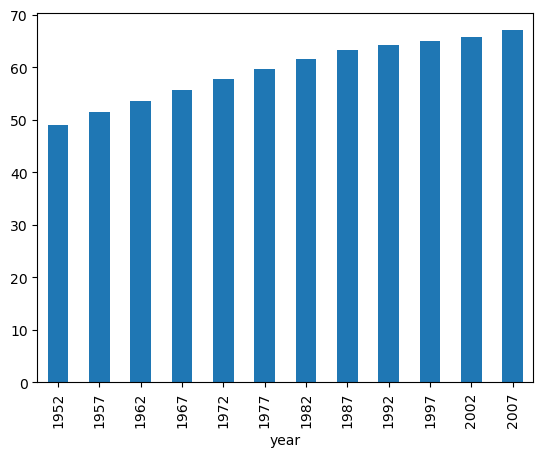

In [54]:
#연도별 평균 기대수명
df.groupby('year')['lifeExp'].mean().plot.bar()
#기준값인 year이 인덱스
# 그래프에서 x축이 인덱스

<Axes: xlabel='year'>

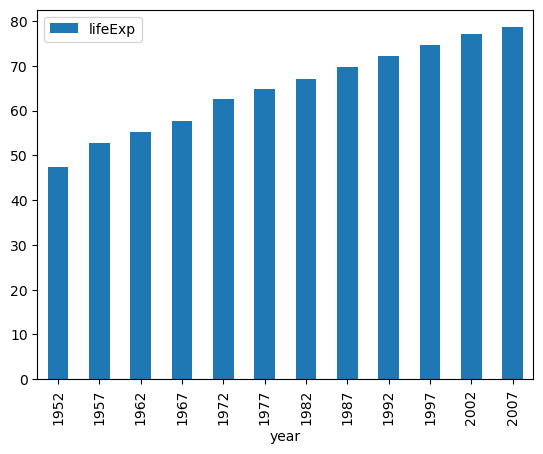

In [60]:
#한국의 연도별 기대수명 그래프로
b1 = df['country'] == 'Korea, Rep.'
df[b1].plot(x='year', y='lifeExp', kind='bar')

In [62]:
import pandas as pd
s1 = pd.Series(['banana',42])
s1

0    banana
1        42
dtype: object

In [66]:
#인덱스 속성 주기
s1 = pd.Series(data=[64,42], index=['홍','박'])
s1


홍    64
박    42
dtype: int64

In [69]:
#인덱스 속성 주기
s1 = pd.Series(data=[64,42])
s1.index='홍,김'.split(',')
s1

홍    64
김    42
dtype: int64

In [67]:
print(s1['홍'])


64


In [73]:
scientists = pd.DataFrame({
    "Name": ["Rosaline Franklin", "William Gosset"],
    "Occupation": ["Chemist", "Statistician"],
    "Born": ["1920-07-25", "1876-06-13"],
    "Died": ["1958-04-16", "1937-10-16"],
    "Age": [37, 61],
})
print(scientists)

                Name    Occupation        Born        Died  Age
0  Rosaline Franklin       Chemist  1920-07-25  1958-04-16   37
1     William Gosset  Statistician  1876-06-13  1937-10-16   61


In [75]:
scientists = pd.DataFrame(
    data={
        "Occupation": ["Chemist", "Statistician"],
        "Born": ["1920-07-25", "1876-06-13"],
        "Died": ["1958-04-16", "1937-10-16"],
        "Age": [37, 61],
    },
    index=["Rosaline Franklin", "William Gosset"],
    columns=["Occupation", "Born", "Died", "Age"],
)
print(scientists)
#가로줄을 레코드라 부름

                     Occupation        Born        Died  Age
Rosaline Franklin       Chemist  1920-07-25  1958-04-16   37
William Gosset     Statistician  1876-06-13  1937-10-16   61


In [78]:
# scientists['William Gosset'] #칼럼명을 의미(열)
scientists.loc['William Gosset']  #행

Occupation    Statistician
Born            1876-06-13
Died            1937-10-16
Age                     61
Name: William Gosset, dtype: object

In [79]:
first_row = scientists.loc['William Gosset']

In [80]:
first_row.index

Index(['Occupation', 'Born', 'Died', 'Age'], dtype='object')

In [82]:
first_row.values #실제값

array(['Statistician', '1876-06-13', '1937-10-16', np.int64(61)],
      dtype=object)

In [83]:
scientists.T

,Rosaline Franklin,William Gosset
Occupation,Chemist,Statistician
Born,1920-07-25,1876-06-13
Died,1958-04-16,1937-10-16
Age,37,61


In [85]:
scientists = pd.read_csv("./data/scientists.csv")
scientists

,Name,Born,Died,Age,Occupation
0,Rosaline Franklin,1920-07-25,1958-04-16,37,Chemist
1,William Gosset,1876-06-13,1937-10-16,61,Statistician
2,Florence Nightingale,1820-05-12,1910-08-13,90,Nurse
3,Marie Curie,1867-11-07,1934-07-04,66,Chemist
4,Rachel Carson,1907-05-27,1964-04-14,56,Biologist
5,John Snow,1813-03-15,1858-06-16,45,Physician
6,Alan Turing,1912-06-23,1954-06-07,41,Computer Scientist
7,Johann Gauss,1777-04-30,1855-02-23,77,Mathematician


In [97]:
ages=scientists['Age']
b1 = ages > ages.mean()
print('mean=',ages.mean())
ages[b1] #평균보다 큰값 출력

mean= 59.125


1    61
2    90
3    66
7    77
Name: Age, dtype: int64

In [98]:
ages + pd.Series([1,2])

0    38.0
1    63.0
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
dtype: float64